<p style="text-align:center; font-size:28px;">Progress Report<br><span style="font-size:14px;">Group 12</span></p>

<p style="text-align:center; font-size:12px">
By: Vitaliy Sosnovyy, Bryce Sadelski, Riya Patel, Siri Arumilli, CJ Casilao<br>
</p>

##### Github
Link: https://github.com/cs418-fa25/project-check-in-team-12/tree/main

---

### Project Introduction

In this project, we explore NBA shot data to understand how shooting success varies across different areas of the court. The dataset includes detailed records for each shot, such as the player and team, shot type, court zones, and whether the shot was made or missed. It also provides information about court zones and their ranges, allowing us to analyze shooting patterns effectively.

Our main research question is: “Which court zones are most effective for a team?”. By analyzing data from the past five seasons, we aim to identify patterns in shooting efficiency across different court zones. Answering this question will help us understand the strengths and weaknesses of teams and provide insights into which areas of the court are most valuable for scoring.


We will accomplish this by analyzing shot-level data, including court zones, shot outcomes, and trends over the past five seasons. By calculating shooting percentages for different zones and visualizing the results with court heatmaps and zone charts, we hope to uncover clear patterns in team performance. These insights may also highlight strategic areas for improvement or emphasis in player and team shooting strategies.


---

### Changes Since Proposal

Our idea of analyzing NBA shots has remained the same, but we have chosen to focus on analyzing shots based on court zones and coordinates, specifically between 2-point and 3-point shot zones to better understand shooting patterns.

We originally planned to analyze individual players, but since there are hundreds of players, this approach was not practical. Instead, we are narrowing the scope to teams, which allows us to provide more meaningful insights into shot patterns and trends. Additionally, we thought about analyzing a 10 year scope in order to eliminate bias and outliers, but we noticed how large that dataset would be. Instead, we decided to focus our attention to the 2023 and 2024 season, which still has over 400,000 rows of data.

We also cleaned our dataset by keeping only the important columns and removing unnecessary columns and rows with missing information. Each shot was then categorized as 2PT or 3PT based on its shot distance. After cleaning, the updated dataset contains all the relevant information, such as team name, shot type, zone, location, and shot distance. The data is more manageable and accurate for our analysis





---

### Data Cleaning/Combining









##### Imports

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Read dataset 

In [6]:
# Read in raw data
shots_df = pd.read_csv("nba_shots.csv")

# Only keep 2023-2024 seasons data
shots_df = shots_df[(shots_df['SEASON_1'] >= 2023) & (shots_df['SEASON_1'] <= 2024)]

# Return number of rows of new range 
print(f"Rows after keeping only 2023-2024 seasons: {shots_df.shape[0]}")
shots_df.head()

# Save new range dataset into new csv file
shots_df.to_csv("nba_shots_cleaned.csv", index=False)

Rows after keeping only 2023-2024 seasons: 435921


##### Check the Shape of the Dataset and if there are any missing values

In [7]:
# Print number of rows & cols
print(f"Dataset shape: {shots_df.shape}")    

# Check for any null-values within dataset
print(f"Missing values:\n{shots_df.isnull().sum()}")

Dataset shape: (435921, 24)
Missing values:
SEASON_1         0
SEASON_2         0
TEAM_ID          0
TEAM_NAME        0
PLAYER_ID        0
PLAYER_NAME      0
GAME_DATE        0
GAME_ID          0
HOME_TEAM        0
AWAY_TEAM        0
EVENT_TYPE       0
SHOT_MADE        0
ACTION_TYPE      0
SHOT_TYPE        0
BASIC_ZONE       0
ZONE_NAME        0
ZONE_ABB         0
ZONE_RANGE       0
LOC_X            0
LOC_Y            0
SHOT_DISTANCE    0
QUARTER          0
MINS_LEFT        0
SECS_LEFT        0
dtype: int64


##### Get rid columns that are not needed

In [8]:
# Cleaning columns we would never need

df = shots_df.drop('EVENT_TYPE', axis=1)
df = shots_df.drop('ACTION_TYPE', axis=1)

print("Removed column: EVENT_TYPE and ACTION_TYPE, it was redundant")

# Add total seconds left column for later analysis
df['TOTAL_SECS_LEFT'] = df['MINS_LEFT'] * 60 + df['SECS_LEFT']

Removed column: EVENT_TYPE and ACTION_TYPE, it was redundant


In [18]:
# data cleaning for zones specifically
shots_df = pd.read_csv("nba_shots_cleaned.csv")

# keep only relevant columns for shot analysis
columns_to_keep = [
    'TEAM_NAME', 'SHOT_TYPE', 'BASIC_ZONE',
    'ZONE_NAME', 'SHOT_DISTANCE', 'SHOT_MADE'
]
shots_df = shots_df[columns_to_keep]


# remove rows missing information
shots_df = shots_df.dropna(subset=['TEAM_NAME', 'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME'])


# check if 2pt or 3pt
def classify_2pt_3pt(distance):
    if distance > 23.75:
        return '3PT'
    else:
        return '2PT'

# create new column using above function to classify 2pt/3pt
shots_df['SHOT_ZONE_CLASS'] = shots_df['SHOT_DISTANCE'].apply(classify_2pt_3pt)

# load new cleaned data into a new csv file
shots_df.to_csv("nba_shots_zone_cleaned.csv", index=False)

print("Data cleaning complete:")
print(shots_df.head())

Data cleaning complete:
            TEAM_NAME       SHOT_TYPE             BASIC_ZONE ZONE_NAME  SHOT_DISTANCE  SHOT_MADE SHOT_ZONE_CLASS
0  Washington Wizards  2PT Field Goal  In The Paint (Non-RA)    Center             12      False             2PT
1  Washington Wizards  3PT Field Goal      Above the Break 3    Center             25       True             3PT
2  Washington Wizards  2PT Field Goal        Restricted Area    Center              3       True             2PT
3  Washington Wizards  2PT Field Goal        Restricted Area    Center              1       True             2PT
4  Washington Wizards  2PT Field Goal        Restricted Area    Center              1       True             2PT


---
### Exploratory Data Analysis


In [9]:
# Total shots per team per zone
team_zone_counts = shots_df.groupby(['TEAM_NAME', 'ZONE_NAME']).size().reset_index(name='Total_Shots')

team_zone_made = shots_df.groupby(['TEAM_NAME', 'ZONE_NAME'])['SHOT_MADE'].sum().reset_index(name='Shots_Made')

team_zone_stats = pd.merge(team_zone_counts, team_zone_made, on=['TEAM_NAME', 'ZONE_NAME'])

team_zone_stats['Shooting_Percent'] = team_zone_stats['Shots_Made'] / team_zone_stats['Total_Shots']

team_zone_stats['Shooting_Percent'] = team_zone_stats['Shooting_Percent'].round(3)

team_zone_stats = team_zone_stats.sort_values(['TEAM_NAME', 'Shooting_Percent'], ascending=[True, False])

team_zone_stats.head(20)

,TEAM_NAME,ZONE_NAME,Total_Shots,Shots_Made,Shooting_Percent
1,Atlanta Hawks,Center,8908,4787,0.537
4,Atlanta Hawks,Right Side,1263,541,0.428
2,Atlanta Hawks,Left Side,1503,597,0.397
3,Atlanta Hawks,Left Side Center,1930,726,0.376
5,Atlanta Hawks,Right Side Center,1528,536,0.351
0,Atlanta Hawks,Back Court,26,0,0.000
7,Boston Celtics,Center,7559,4257,0.563
10,Boston Celtics,Right Side,1261,546,0.433
8,Boston Celtics,Left Side,1236,517,0.418
11,Boston Celtics,Right Side Center,2202,840,0.381


In [10]:

top_teams_per_zone = {}

# find top team per zone
for zone in team_zone_stats['ZONE_NAME'].unique():                    
    zone_df = team_zone_stats[team_zone_stats['ZONE_NAME'] == zone]
    top_team = zone_df.loc[zone_df['Shooting_Percent'].idxmax()]
    top_teams_per_zone[zone] = {
        'Team': top_team['TEAM_NAME'],
        'Shooting_Percent': top_team['Shooting_Percent'],
        'Shots_Made': top_team['Shots_Made'],
        'Total_Shots': top_team['Total_Shots']
    }

# Display results
import pandas as pd
top_teams_df = pd.DataFrame(top_teams_per_zone).T.reset_index()
top_teams_df.rename(columns={'index': 'ZONE_NAME'}, inplace=True)
pd.set_option('display.width', 1000)
print(top_teams_df)

           ZONE_NAME                Team Shooting_Percent Shots_Made Total_Shots
0             Center  Los Angeles Lakers            0.577       4898        8484
1         Right Side         LA Clippers            0.442        603        1364
2          Left Side        Phoenix Suns             0.45        743        1652
3   Left Side Center     Milwaukee Bucks            0.388        844        2178
4  Right Side Center         LA Clippers            0.402        787        1958
5         Back Court  Washington Wizards            0.114          4          35


---
#### Preliminary Conculusion
Across the NBA, different teams excel in different court zones. This suggests that each team has unique offensive identities which built around thier strengths, rather than being equally efficient across the entire court.



For example, most teams show their highest shooting percentages near the center area, with the Los Angeles Lakers (0.577), Atlanta Hawks (0.537) and Boston Celtics (0.563) leading in efficiency there. Teams
also show variability in their performance on the wings and mid-range zones. The Atlanta Hawks and LA Clippers have stronger percentages on the Right Side, while others like the Phoenix Suns and Milwaukee Bucks perform better on the Left Side or Left Side Center. Understanding these zone-based efficiencies can help predict future game outcomes, as teams that use their most efficient zones are more likely to achieve higher scoring success in the upcoming NBA seasons.








---

### Visualizations












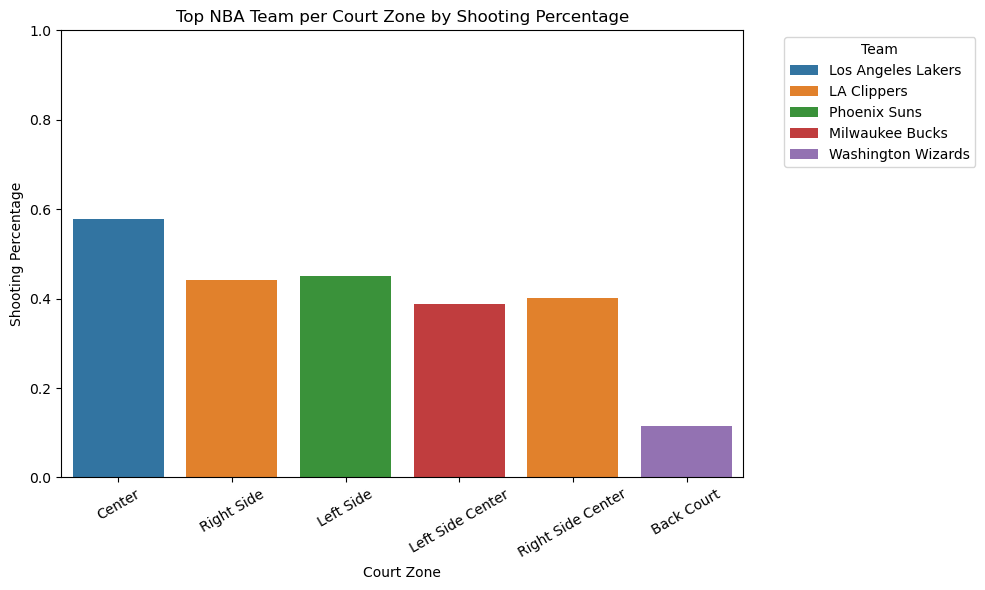

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create bar-plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_teams_df,
    x='ZONE_NAME',
    y='Shooting_Percent',
    hue='Team',
)

plt.title('Top NBA Team per Court Zone by Shooting Percentage')
plt.xlabel('Court Zone')
plt.ylabel('Shooting Percentage')
plt.ylim(0, 1)  

plt.xticks(rotation=30)
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We hypothesized that different NBA teams would emerge as the most efficient shooters depending on the court zone. To test this, we calculated shooting percentages by team and zone, and then identified the top performer in each area. The results show that the Lakers are the best team in the paint (around the basket), the Clippers excel on the right side, the Suns lead from the left wing, while the desparation shots (beyond the midcourt line) belong to the Washington Wizards. This supports the idea that team strengths are court zone-specific, which indicate unique offensive identities and play styles.

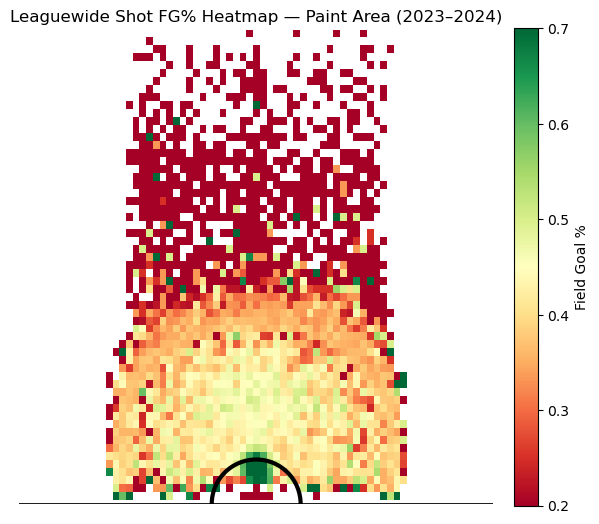

In [12]:
from matplotlib.patches import Circle, Rectangle

df_23_24 = shots_df[(shots_df['SEASON_1'] >= 2023) & (shots_df['SEASON_1'] <= 2024)].copy()
if df_23_24['SHOT_MADE'].dtype != bool:
    df_23_24['SHOT_MADE'] = df_23_24['SHOT_MADE'].astype(str).str.lower().map({'true': True, 'false': False, '1': True, '0': False})

heat_df = df_23_24[(df_23_24['LOC_X'].between(-80, 80)) & (df_23_24['LOC_Y'].between(0, 190))].copy()
heat = heat_df[['LOC_X','LOC_Y','SHOT_MADE']].dropna()

xbins = np.linspace(-80, 80, 140)
ybins = np.linspace(0, 190, 140)

xcat = pd.cut(heat['LOC_X'], bins=xbins, include_lowest=True)
ycat = pd.cut(heat['LOC_Y'], bins=ybins, include_lowest=True)

grid = (heat.assign(xbin=xcat, ybin=ycat).groupby(['xbin','ybin'], observed=False).agg(Total=('SHOT_MADE','size'), Made=('SHOT_MADE','sum')).reset_index())
grid['FG_Pct'] = grid['Made'] / grid['Total']

def mid(iv): 
    return np.nan if pd.isna(iv) else (iv.left + iv.right) / 2
grid['xc'] = grid['xbin'].apply(mid)
grid['yc'] = grid['ybin'].apply(mid)

pivot = grid.pivot_table(index='yc', columns='xc', values='FG_Pct', aggfunc='mean', observed=False)
arr = np.array(pivot)
extent = [pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()]

fig, ax = plt.subplots(figsize=(6, 7))
ax.add_patch(Rectangle((-80, 0), 160, 190, lw=1.2, fill=False, color='black'))
ax.add_patch(Rectangle((-60, 0), 120, 190, lw=1.0, fill=False, color='black'))
ax.add_patch(Circle((0, 0), radius=7.5, lw=3, fill=False, color='black'))

im = ax.imshow(arr, extent=extent, origin='lower', vmin=0.2, vmax=0.7, cmap='RdYlGn')
ax.set_xlim(-40, 40)
ax.set_ylim(0, 80)
ax.set_aspect('equal', adjustable='box')
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Field Goal %')
ax.set_title("Leaguewide Shot FG% Heatmap — Paint Area (2023–2024)")
plt.tight_layout()
plt.show()


This heatmap visualizes the leaguewide field goal percentage (FG%) for all NBA teams within the paint area during the 2023–2024 seasons. Each colored square represents a small region on the court, and the color indicates how efficiently players score from that location.

Areas near the basket (the hoop) appear in green and yellow, meaning these locations have the highest shooting success rates, typically ranging from 60–70% FG. This aligns with basketball expectations—layups and dunks are the most efficient scoring opportunities because they occur close to the rim, often uncontested or assisted.

---
### Prediction/Dependent variable on Dataset

The dependent variable selected for modeling is 'SHOT_MADE'. This is simply a binary indicatory (True = made, False = missed). The goal of the model would is to predict the probability that a given shot attempt results in a make.

The features/independent variables used to predict 'SHOT_MADE' will be the same as the columns from the 'nba_shots_zone_cleaned.csv' file: 'TEAM_NAME', 'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'SHOT_DISTANCE' along with 'TOTAL_SECS_LEFT'.

By modeling 'SHOT_MADE' as a binary classifcation problem, we can build a model to estimate the probability of success for any given shot attempt and identify which factors most strongly affect efficiency.


---


### Reflection

- The hardest part so far was deciding what range of NBA seasons to analyze. Our initial plan was to look at the past 5 seasons but that alone would result in processing over one million rows of data, which seemed excessive. Instead, we narrowed the focus to the 2023 & 2024 seasons. Even with this smaller range, the dataset still contains over 40,000 rows after filtering, which provides sufficient depth for meaningful analysis.

- Some initial insights include: Zone-specific dominance (no single team is universally efficient across all court zones), Interior vs. Perimeter efficiency (interior zones tend to favor teams with strong bigs, while perimeter zones tend to favor teams with elite shooters). 

- Right now, the concrete results we can show are the top teams in each court zone by shooting percentage. We have also observed that interior zones (paint) generally yield higher efficiency than perimeter zones.

-  One of the main challenges at the moment is determining the best modeling approach for predicting shot success. We have a clean dataset, but selecting needed features and model type will require experimentation. Another challenge is visualizing large amounts of data clearly without overcrowding the graphs, especially since there is overlapping data. 

- Yes, we are on track with the project, specifically the data cleaning and exploration, as we have most of what we will need to build and test a prediction model. The next steps for us is to build the predictive model, evaluate and test/fine tune it. We want to eventually test the model based on this seasons games. 

- Yes, the initial findings are great and we all as a group agreed on proceeding with the project. We have already determined zone specific shooting strengths and percentages for different teams, which aligns with our main hypothesis. By creating a prediction model, we can create something more analytical and see new team trends. 

---


### Roles/Coordination

- Data Cleaning & Preprocessing (Riya & Siri) - Maintain clean datasets, handle null/missing values, ensure data is correct for modeling and machine learning. ***Deadline to complete by Nov 7th***

- Exploratory Data Analysis (Bryce & CJ) - Zone charts, bar plots, visualization of data sets and trends. ***Deadline to complete by Nov 14th***

- Evaluation & Modeling/ML Application (Vitaliy & Siri) - Build and train models to predict future NBA games, test model and evaluate/adjust based on performance. ***Deadline to complete by Nov 30th***

- Documentation & Presentation (Vitaliy & CJ & Siri) - Summarize the findings, create slides, write reflection and interpretation, final report and demos. ***Everything finalized and submitted by Dec 5th***


***All aspects will be collaborated with all group members and the final group project will be a team collaboration***

---


### Next Steps

By the end of this timeline, the project will have a working shot/win predictive model, great visuals, and clear strategic insights about NBA team zone efficiency. This will allow us to not only identify where teams perform best on the court but also predict how these zone based efficiencies can influence overall game outcomes and competitive advantages. We will evaluate ourselves and our model based on real data from future upcoming games this 2025-26 NBA season. 

---
